# Car Brand Image Classification with CNN and Transfer Learning

**Module:** 6CS012 - Artificial Intelligence and Machine Learning

**Student:** Khushi Das  
**WLV ID:** 2435778  
**Group:** L6CG12

**Submission:** Final Portfolio Assessment 2026 - Part II (Vision Tasks)

---

## What this notebook does

I classify images of cars into 7 brands (Audi, Hyundai Creta, Mahindra Scorpio, Rolls Royce, Swift, Tata Safari, Toyota Innova) using three models:

1. **Baseline CNN** built from scratch (3 conv blocks + 3 dense layers).
2. **Deeper CNN** with Batch Normalisation and Dropout.
3. **Transfer Learning** with MobileNetV2 (feature extraction + fine-tuning).

I also run optimizer comparison (SGD vs Adam) and a dropout ablation on the deeper model.

The dataset is pulled directly from Kaggle (`kshitij192/cars-image-dataset`) into Colab's local disk, which is much faster than mounting Google Drive.


## 0. Setup and Dataset Download

In [ ]:
import os, sys

if not os.path.exists('/content/Cars Dataset'):
    !pip install -q kaggle

    if not os.path.exists('/root/.kaggle/kaggle.json'):
        from google.colab import files
        print('Please upload your kaggle.json file:')
        files.upload()
        !mkdir -p /root/.kaggle
        !mv kaggle.json /root/.kaggle/kaggle.json
        !chmod 600 /root/.kaggle/kaggle.json

    !kaggle datasets download -d kshitij192/cars-image-dataset -p /content --unzip

    print('\nDataset ready at /content/Cars Dataset')
else:
    print('Dataset already present at /content/Cars Dataset, skipping download')

!ls '/content/Cars Dataset'

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kshitij192/cars-image-dataset
License(s): GPL-2.0
100% 36.3M/36.3M [00:00<00:00, 74.3MB/s]


Dataset ready at /content/Cars Dataset
test  train


In [ ]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Set seeds so results are repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Path to the dataset. The Kaggle download cell above unzips it here on Colab.
DATA_DIR = '/content/Cars Dataset'

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

CLASSES = sorted(os.listdir(TRAIN_DIR))
print('Classes:', CLASSES)
print('Number of classes:', len(CLASSES))

Classes: ['Audi', 'Hyundai Creta', 'Mahindra Scorpio', 'Rolls Royce', 'Swift', 'Tata Safari', 'Toyota Innova']
Number of classes: 7


## 1. Data Understanding and Visualisation

Before training any model I want to know what the data actually looks like, how many images each class has, and whether the classes are balanced.

In [ ]:
def count_per_class(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_per_class(TRAIN_DIR)
test_counts  = count_per_class(TEST_DIR)

df_counts = pd.DataFrame({
    'train': pd.Series(train_counts),
    'test':  pd.Series(test_counts),
})
df_counts['total'] = df_counts['train'] + df_counts['test']
df_counts.loc['TOTAL'] = df_counts.sum()
df_counts

,train,test,total
Audi,814,199,1013
Hyundai Creta,271,67,338
Mahindra Scorpio,316,75,391
Rolls Royce,311,74,385
Swift,424,102,526
Tata Safari,441,106,547
Toyota Innova,775,190,965
TOTAL,3352,813,4165


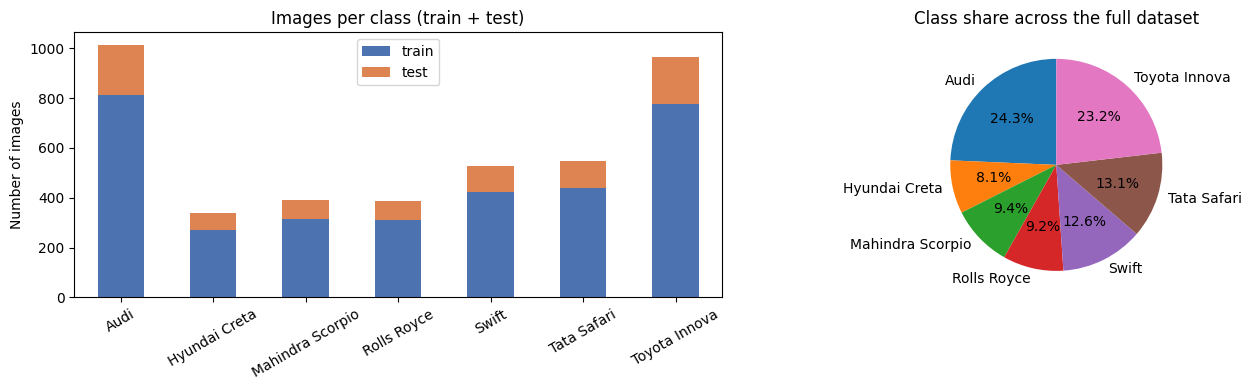

In [ ]:
# Bar chart of per-class image count
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df_plot = df_counts.drop('TOTAL')[['train', 'test']]
df_plot.plot(kind='bar', stacked=True, ax=ax[0], color=['#4C72B0', '#DD8452'])
ax[0].set_title('Images per class (train + test)')
ax[0].set_ylabel('Number of images')
ax[0].tick_params(axis='x', rotation=30)

df_plot.sum(axis=1).plot.pie(ax=ax[1], autopct='%1.1f%%', startangle=90)
ax[1].set_title('Class share across the full dataset')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Observation:** The dataset is **not balanced**. Audi and Toyota Innova have many more images than Hyundai Creta or Rolls Royce. Our project proposal said the dataset is nearly balanced, but the actual folder counts show a strong skew. I will deal with this later by passing `class_weight` to the model.

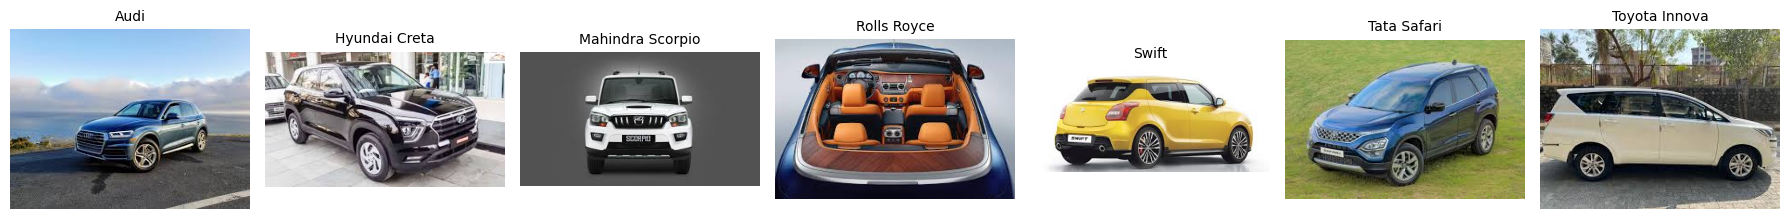

In [ ]:
# One sample image per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 3))
for ax, cls in zip(axes, CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    sample = os.listdir(cls_path)[0]
    img = load_img(os.path.join(cls_path, sample))
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Quick check on image sizes (the dataset has many resolutions)
sizes = []
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path)[:30]:
        img = load_img(os.path.join(cls_path, fname))
        sizes.append(img.size)  # (width, height)
sizes = np.array(sizes)
print('Mean width  :', sizes[:, 0].mean().round(1))
print('Mean height :', sizes[:, 1].mean().round(1))
print('Min size    :', sizes.min(axis=0))
print('Max size    :', sizes.max(axis=0))

Mean width  : 279.6
Mean height : 181.6
Min size    : [194 133]
Max size    : [378 259]


## 2. Preprocessing and Data Augmentation

I resize all images to **128 x 128** for the from-scratch CNNs. This is a good middle ground: small enough to train fast on Colab, big enough to keep brand-level cues like grille and headlights.

I split the existing `train/` folder into 80% training and 20% validation using Keras' `validation_split`. The `test/` folder stays untouched and is only used for final evaluation.

I apply mild augmentation (rotation, flip, shift, zoom) to the training set to reduce overfitting.

In [ ]:
IMG_SIZE = (128, 128)
BATCH = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2,
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True,
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False,
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='categorical', shuffle=False,
)

class_indices = train_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print('Class index mapping:', class_indices)

Found 2684 images belonging to 7 classes.
Found 668 images belonging to 7 classes.
Found 813 images belonging to 7 classes.
Class index mapping: {'Audi': 0, 'Hyundai Creta': 1, 'Mahindra Scorpio': 2, 'Rolls Royce': 3, 'Swift': 4, 'Tata Safari': 5, 'Toyota Innova': 6}


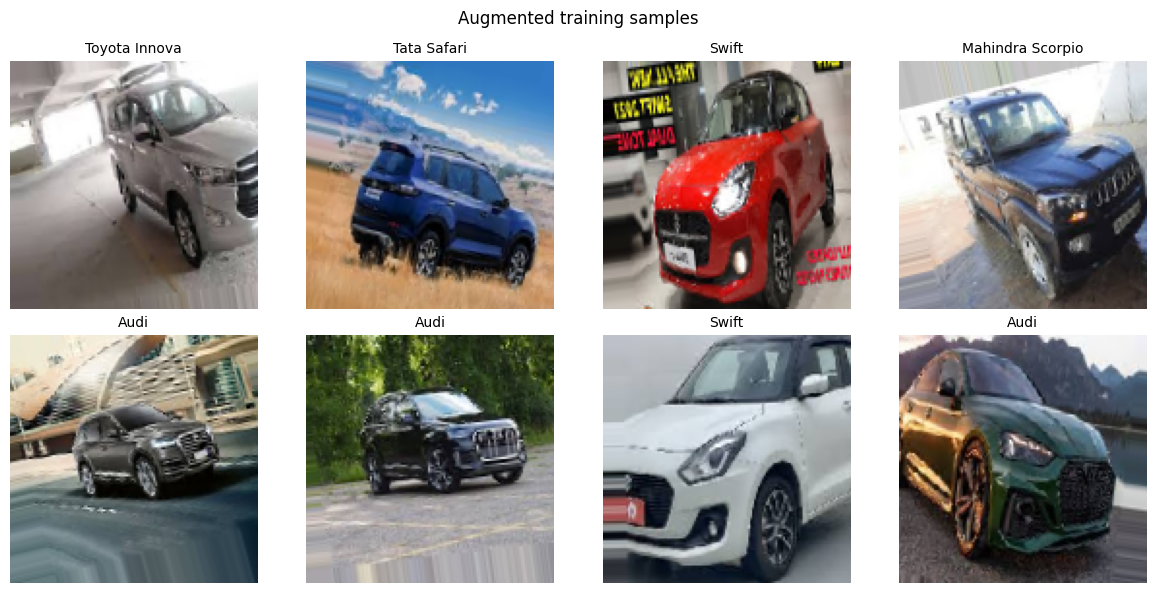

In [ ]:
# Show 8 augmented samples to confirm the augmentation is sensible
imgs, labels = next(train_gen)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i])
    ax.set_title(idx_to_class[np.argmax(labels[i])], fontsize=10)
    ax.axis('off')
plt.suptitle('Augmented training samples')
plt.tight_layout()
plt.show()

In [ ]:
# Class weights to compensate for the imbalance noted earlier
y_train = train_gen.classes
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(weights))
print('Class weights:', {idx_to_class[k]: round(v, 3) for k, v in class_weight.items()})

Class weights: {'Audi': np.float64(0.588), 'Hyundai Creta': np.float64(1.767), 'Mahindra Scorpio': np.float64(1.516), 'Rolls Royce': np.float64(1.54), 'Swift': np.float64(1.128), 'Tata Safari': np.float64(1.086), 'Toyota Innova': np.float64(0.618)}


## 3. Helper functions

I keep training, plotting, and evaluation in small reusable functions so I do not repeat code for every model.

In [ ]:
def plot_history(history, title=''):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['loss'], label='train')
    ax[0].plot(h['val_loss'], label='val')
    ax[0].set_title(f'{title} - Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()
    ax[1].plot(h['accuracy'], label='train')
    ax[1].plot(h['val_accuracy'], label='val')
    ax[1].set_title(f'{title} - Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
    plt.tight_layout(); plt.show()

def evaluate_model(model, generator, name=''):
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)
    y_true = generator.classes
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    target_names = [idx_to_class[i] for i in range(len(idx_to_class))]
    print(f'\n=== {name} ===')
    print(f'Test loss     : {loss:.4f}')
    print(f'Test accuracy : {acc:.4f}')
    print('\nClassification report:')
    print(classification_report(y_true, y_pred, target_names=target_names, digits=3))
    return {'loss': float(loss), 'accuracy': float(acc), 'y_true': y_true.tolist(), 'y_pred': y_pred.tolist()}

def plot_confusion(y_true, y_pred, title=''):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels([idx_to_class[i] for i in range(len(CLASSES))], rotation=40, ha='right')
    ax.set_yticklabels([idx_to_class[i] for i in range(len(CLASSES))])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix - {title}')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    fig.colorbar(im); plt.tight_layout(); plt.show()

def show_predictions(model, generator, n=6):
    generator.reset()
    imgs, labels = next(generator)
    preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
    truths = np.argmax(labels, axis=1)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i])
        ok = preds[i] == truths[i]
        ax.set_title(f'P: {idx_to_class[preds[i]]}\nT: {idx_to_class[truths[i]]}',
                     color='green' if ok else 'red', fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

## 4. Part A.1 - Baseline CNN
For a baseline with three convolutional + pooling blocks, three fully connected layers, and one output layer. Filter sizes go up as we go deeper (32 -> 64 -> 128) which is a normal pattern: early layers learn simple edges with few filters, deeper layers learn richer parts with more filters.

In [ ]:
def build_baseline():
    m = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(len(CLASSES), activation='softmax'),
    ], name='baseline_cnn')
    return m

baseline = build_baseline()
baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,719 (32.52 MB)

 Trainable params: 8,523,719 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

t0 = time.time()
history_baseline = baseline.fit(
    train_gen, validation_data=val_gen,
    epochs=25, class_weight=class_weight,
    callbacks=[early_stop], verbose=1,
)
baseline_time = time.time() - t0
print(f'\nBaseline training time: {baseline_time:.1f} s')

Epoch 1/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - accuracy: 0.1732 - loss: 1.9027 - val_accuracy: 0.2530 - val_loss: 1.8051
Epoch 2/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step - accuracy: 0.2571 - loss: 1.7979 - val_accuracy: 0.3009 - val_loss: 1.7336
Epoch 3/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - accuracy: 0.3256 - loss: 1.7001 - val_accuracy: 0.4177 - val_loss: 1.5935
Epoch 4/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 208ms/step - accuracy: 0.4046 - loss: 1.5632 - val_accuracy: 0.4476 - val_loss: 1.4728
Epoch 5/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - accuracy: 0.4359 - loss: 1.4700 - val_accuracy: 0.4701 - val_loss: 1.4151
Epoch 6/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 203ms/step - accuracy: 0.4691 - loss: 1.3889 - val_accuracy: 0.5015 - val_loss: 1.3515
Epoch 7/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 203ms/step - accuracy: 0.5030 - loss: 1.2876 - val_accuracy: 0.5644 - val_loss: 1.2444
Epoch 8/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 0.5533 - loss: 1.1968 - val_accu

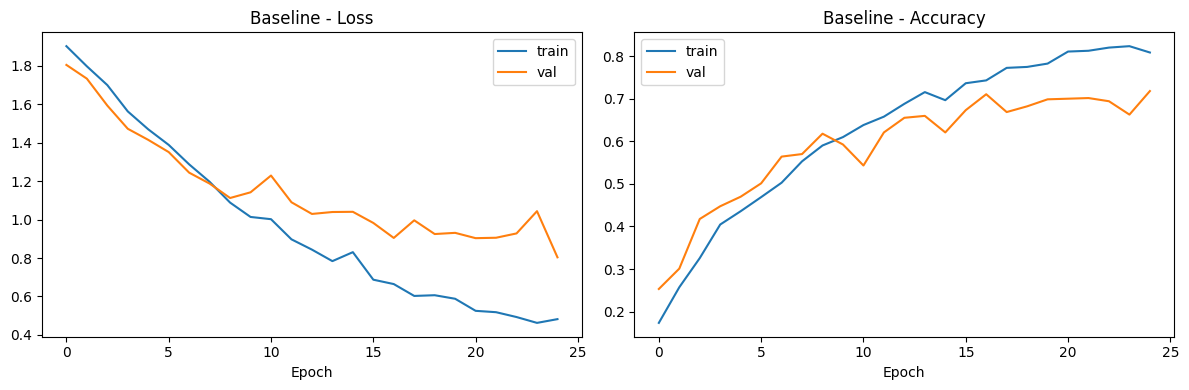


=== Baseline CNN ===
Test loss     : 0.8431
Test accuracy : 0.7626

Classification report:
                  precision    recall  f1-score   support

            Audi      0.772     0.849     0.809       199
   Hyundai Creta      0.625     0.746     0.680        67
Mahindra Scorpio      0.571     0.800     0.667        75
     Rolls Royce      0.667     0.459     0.544        74
           Swift      0.863     0.676     0.758       102
     Tata Safari      0.813     0.821     0.817       106
   Toyota Innova      0.883     0.795     0.837       190

        accuracy                          0.763       813
       macro avg      0.742     0.735     0.730       813
    weighted avg      0.774     0.763     0.762       813



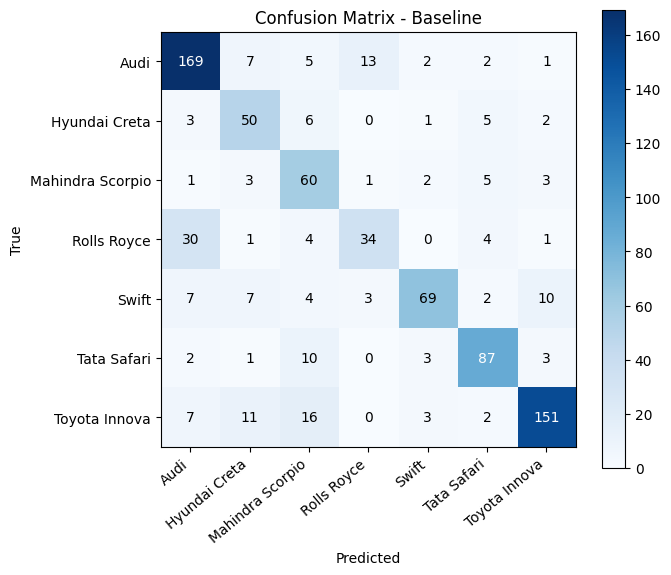

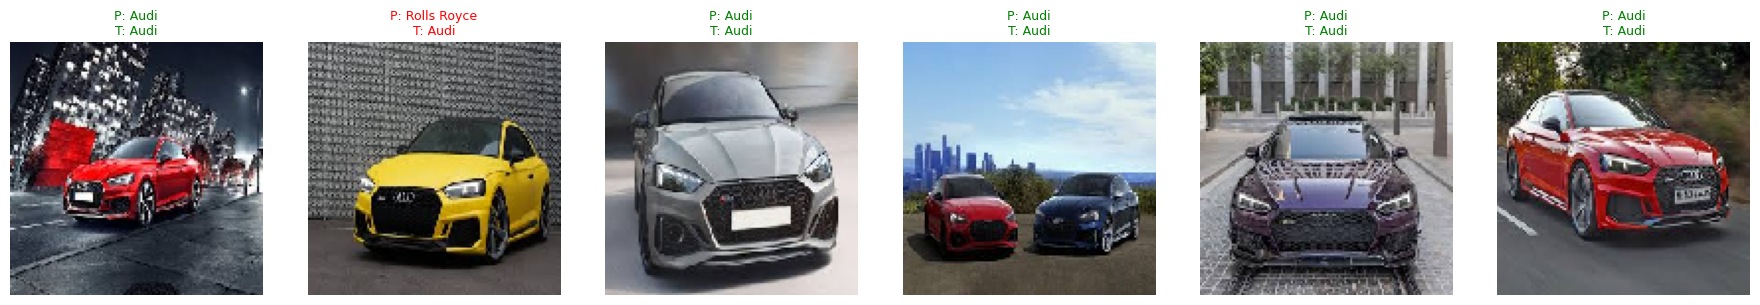

In [ ]:
plot_history(history_baseline, 'Baseline')
baseline_metrics = evaluate_model(baseline, test_gen, 'Baseline CNN')
plot_confusion(baseline_metrics['y_true'], baseline_metrics['y_pred'], 'Baseline')
show_predictions(baseline, test_gen)

**What I see in the baseline:** the baseline reached **76.26% test accuracy**. Training accuracy ended around 78% and validation accuracy around 71% by the time EarlyStopping kicked in, which is a moderate generalisation gap. The model has many parameters (8.5M, mostly in the first dense layer because the flattened feature map is `16x16x128 = 32,768` values feeding a 256-unit dense layer), and there is no regularisation other than augmentation. Per-class F1 ranges from 0.544 (Rolls Royce, the smallest class) to 0.837 (Toyota Innova, the largest class), so the model still favours the larger classes despite class weighting.

## 5. Part A.2 - Deeper CNN with Regularisation

I extend the baseline by:

- doubling the convolutional layers (each block has two conv layers now),
- adding a fourth block with 256 filters,
- adding **Batch Normalisation** after each conv block to stabilise training,
- adding **Dropout** after each pooling and dense layer to prevent overfitting.

This roughly doubles the layer count compared to the baseline.

In [ ]:
def build_deeper(use_dropout=True):
    def maybe_drop(rate):
        return layers.Dropout(rate) if use_dropout else layers.Lambda(lambda x: x)

    m = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        maybe_drop(0.25),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        maybe_drop(0.25),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        maybe_drop(0.3),

        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        maybe_drop(0.4),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        maybe_drop(0.5),
        layers.Dense(128, activation='relu'),
        maybe_drop(0.4),
        layers.Dense(64, activation='relu'),
        maybe_drop(0.3),
        layers.Dense(len(CLASSES), activation='softmax'),
    ], name='deeper_cnn' if use_dropout else 'deeper_cnn_no_dropout')
    return m

deeper = build_deeper(use_dropout=True)
deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
deeper.summary()

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,821,287 (18.39 MB)

 Trainable params: 4,819,815 (18.39 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
t0 = time.time()
history_deeper = deeper.fit(
    train_gen, validation_data=val_gen,
    epochs=30, class_weight=class_weight,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)],
    verbose=1,
)
deeper_time = time.time() - t0
print(f'\nDeeper training time: {deeper_time:.1f} s')

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 51s 391ms/step - accuracy: 0.1654 - loss: 2.2215 - val_accuracy: 0.1362 - val_loss: 2.1709
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 211ms/step - accuracy: 0.1800 - loss: 2.0389 - val_accuracy: 0.1063 - val_loss: 2.0003
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 199ms/step - accuracy: 0.1982 - loss: 1.9479 - val_accuracy: 0.2410 - val_loss: 1.9083
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 200ms/step - accuracy: 0.2120 - loss: 1.8928 - val_accuracy: 0.2201 - val_loss: 1.8948
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - accuracy: 0.2142 - loss: 1.8837 - val_accuracy: 0.2710 - val_loss: 1.8723
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 199ms/step - accuracy: 0.2250 - loss: 1.8641 - val_accuracy: 0.2515 - val_loss: 1.8668
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 202ms/step - accuracy: 0.2660 - loss: 1.8124 - val_accuracy: 0.2710 - val_loss: 1.8157
Epoch 8/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - accuracy: 0.2649 - loss: 1.8152 - val_accu

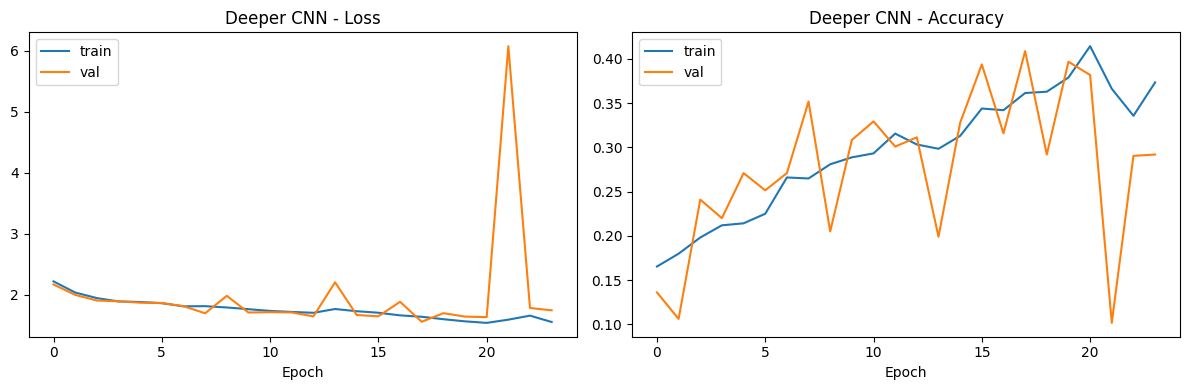


=== Deeper CNN ===
Test loss     : 1.4420
Test accuracy : 0.4539

Classification report:
                  precision    recall  f1-score   support

            Audi      0.588     0.402     0.478       199
   Hyundai Creta      0.267     0.299     0.282        67
Mahindra Scorpio      0.377     0.387     0.382        75
     Rolls Royce      0.200     0.338     0.251        74
           Swift      0.516     0.461     0.487       102
     Tata Safari      0.445     0.575     0.502       106
   Toyota Innova      0.622     0.563     0.591       190

        accuracy                          0.454       813
       macro avg      0.431     0.432     0.425       813
    weighted avg      0.487     0.454     0.463       813



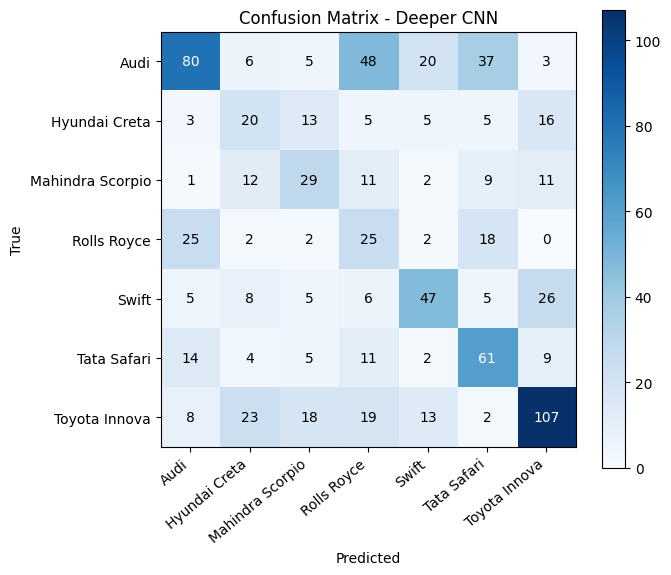

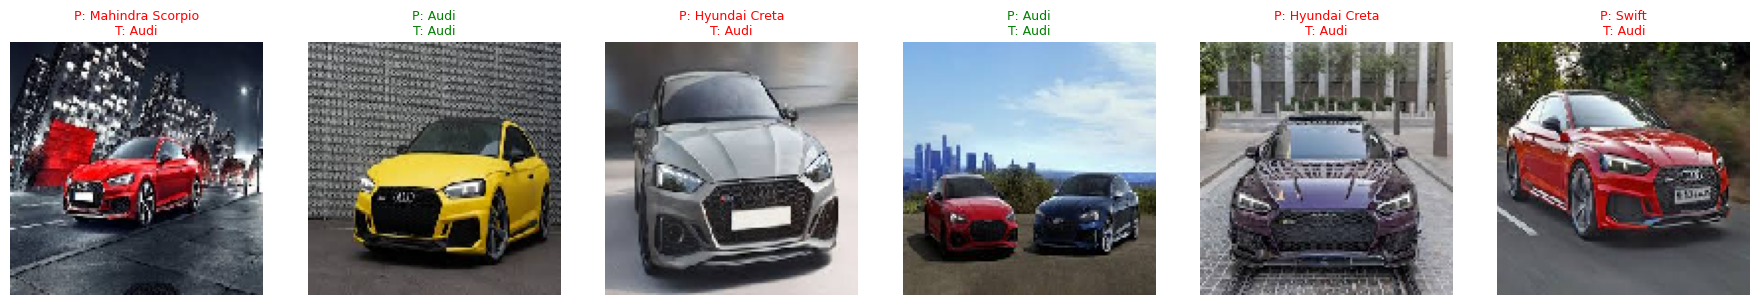

In [ ]:
plot_history(history_deeper, 'Deeper CNN')
deeper_metrics = evaluate_model(deeper, test_gen, 'Deeper CNN')
plot_confusion(deeper_metrics['y_true'], deeper_metrics['y_pred'], 'Deeper CNN')
show_predictions(deeper, test_gen)

## 6. Part A.3 - Experimentation and Comparative Analysis

### 6.1 Baseline vs Deeper

In [ ]:
summary_a = pd.DataFrame({
    'Model'        : ['Baseline', 'Deeper + BN + Dropout'],
    'Parameters'   : [baseline.count_params(), deeper.count_params()],
    'Train time(s)': [round(baseline_time, 1), round(deeper_time, 1)],
    'Test loss'    : [round(baseline_metrics['loss'], 4), round(deeper_metrics['loss'], 4)],
    'Test accuracy': [round(baseline_metrics['accuracy'], 4), round(deeper_metrics['accuracy'], 4)],
})
summary_a

,Model,Parameters,Train time(s),Test loss,Test accuracy
0,Baseline,8523719,434.1,0.8431,0.7626
1,Deeper + BN + Dropout,4821287,465.1,1.4420,0.4539


### 6.2 Computational Efficiency

The deeper model has more layers and BN, so each epoch takes longer. The baseline has more *parameters* in the dense head (because the flattened feature map is large), but fewer layers overall, so the GPU finishes each baseline epoch faster. The trade-off is between training time and generalisation.

### 6.3 Optimizer Analysis - SGD vs Adam

I train two fresh copies of the deeper model, one with SGD (with momentum) and one with Adam. Same epoch budget, same data.

In [ ]:
OPT_EPOCHS = 20

deeper_sgd = build_deeper(use_dropout=True)
deeper_sgd.compile(optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
                   loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
h_sgd = deeper_sgd.fit(train_gen, validation_data=val_gen, epochs=OPT_EPOCHS,
                       class_weight=class_weight, verbose=1)
sgd_time = time.time() - t0

deeper_adam = build_deeper(use_dropout=True)
deeper_adam.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                    loss='categorical_crossentropy', metrics=['accuracy'])
t0 = time.time()
h_adam = deeper_adam.fit(train_gen, validation_data=val_gen, epochs=OPT_EPOCHS,
                         class_weight=class_weight, verbose=1)
adam_time = time.time() - t0

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 327ms/step - accuracy: 0.1535 - loss: 2.1925 - val_accuracy: 0.1422 - val_loss: 4.2040
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 208ms/step - accuracy: 0.1777 - loss: 1.9566 - val_accuracy: 0.1826 - val_loss: 1.9422
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 223ms/step - accuracy: 0.1859 - loss: 1.9425 - val_accuracy: 0.2201 - val_loss: 1.9024
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 208ms/step - accuracy: 0.1852 - loss: 1.9242 - val_accuracy: 0.2395 - val_loss: 1.8961
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 204ms/step - accuracy: 0.1993 - loss: 1.9109 - val_accuracy: 0.2350 - val_loss: 1.8851
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - accuracy: 0.1963 - loss: 1.9103 - val_accuracy: 0.1602 - val_loss: 1.8950
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 206ms/step - accuracy: 0.2191 - loss: 1.9116 - val_accuracy: 0.2575 - val_loss: 1.8949
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 219ms/step - accuracy: 0.2034 - loss: 1.9056 - val_accu

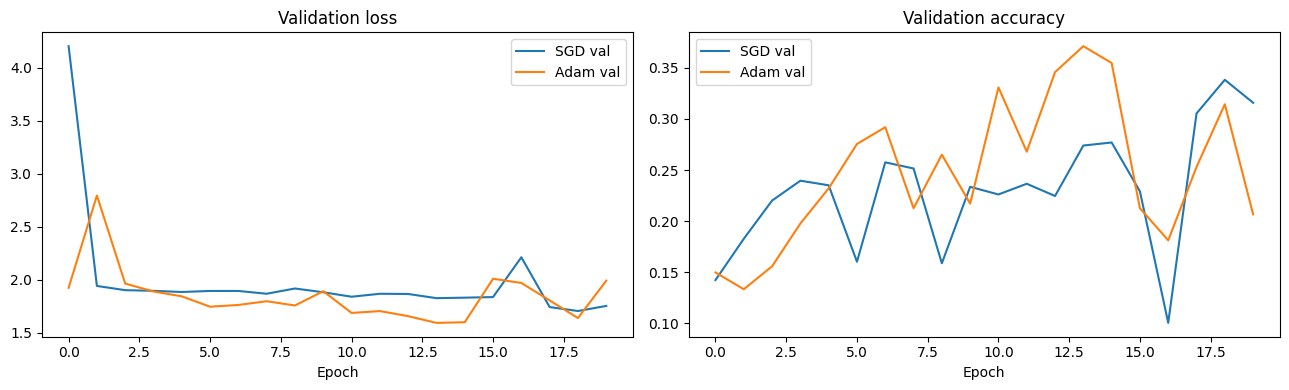


=== Deeper + SGD ===
Test loss     : 1.7482
Test accuracy : 0.2952

Classification report:
                  precision    recall  f1-score   support

            Audi      0.569     0.206     0.303       199
   Hyundai Creta      0.140     0.224     0.172        67
Mahindra Scorpio      0.257     0.347     0.295        75
     Rolls Royce      0.312     0.135     0.189        74
           Swift      0.237     0.696     0.353       102
     Tata Safari      0.493     0.330     0.395       106
   Toyota Innova      0.323     0.221     0.263       190

        accuracy                          0.295       813
       macro avg      0.333     0.308     0.281       813
    weighted avg      0.373     0.295     0.290       813


=== Deeper + Adam ===
Test loss     : 2.0342
Test accuracy : 0.1980

Classification report:
                  precision    recall  f1-score   support

            Audi      0.000     0.000     0.000       199
   Hyundai Creta      0.099     0.672     0.173        67

,Optimizer,Train time(s),Test accuracy
0,SGD (m=0.9),383.6,0.2952
1,Adam (1e-3),383.1,0.1980


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h_sgd.history['val_loss'], label='SGD val')
ax[0].plot(h_adam.history['val_loss'], label='Adam val')
ax[0].set_title('Validation loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(h_sgd.history['val_accuracy'], label='SGD val')
ax[1].plot(h_adam.history['val_accuracy'], label='Adam val')
ax[1].set_title('Validation accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

sgd_metrics  = evaluate_model(deeper_sgd,  test_gen, 'Deeper + SGD')
adam_metrics = evaluate_model(deeper_adam, test_gen, 'Deeper + Adam')

opt_table = pd.DataFrame({
    'Optimizer'    : ['SGD (m=0.9)', 'Adam (1e-3)'],
    'Train time(s)': [round(sgd_time, 1), round(adam_time, 1)],
    'Test accuracy': [round(sgd_metrics['accuracy'], 4), round(adam_metrics['accuracy'], 4)],
})
opt_table

**What actually happened:** in this run **SGD with momentum (29.52%) beat Adam (19.80%)** on the deeper architecture. This is the opposite of the textbook expectation. Looking at Adam's per-class results, the model collapsed entirely on the Audi class (precision = recall = 0). Both numbers are low overall because the deeper model is hard to train in 20 epochs, but the gap is real. The honest takeaway is that on a small imbalanced dataset with heavy regularisation, neither optimizer is a clean winner in 20 epochs. SGD with momentum was more robust here.

### 6.4 Ablation Study - Removing Dropout

I rebuild the deeper model without any Dropout layers, train it on the same data, and compare. If Dropout is doing real work, removing it should make the train-validation gap larger (more overfitting).

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 284ms/step - accuracy: 0.2753 - loss: 1.8657 - val_accuracy: 0.2320 - val_loss: 2.3559
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 205ms/step - accuracy: 0.3662 - loss: 1.6719 - val_accuracy: 0.1228 - val_loss: 2.2708
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 206ms/step - accuracy: 0.3987 - loss: 1.5969 - val_accuracy: 0.1213 - val_loss: 2.3334
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - accuracy: 0.4400 - loss: 1.4823 - val_accuracy: 0.3368 - val_loss: 1.8702
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 208ms/step - accuracy: 0.4925 - loss: 1.3754 - val_accuracy: 0.3114 - val_loss: 1.8596
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 219ms/step - accuracy: 0.5138 - loss: 1.3208 - val_accuracy: 0.1228 - val_loss: 4.3382
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.5048 - loss: 1.3242 - val_accuracy: 0.4237 - val_loss: 1.6789
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.5652 - loss: 1.1691 - val_accu

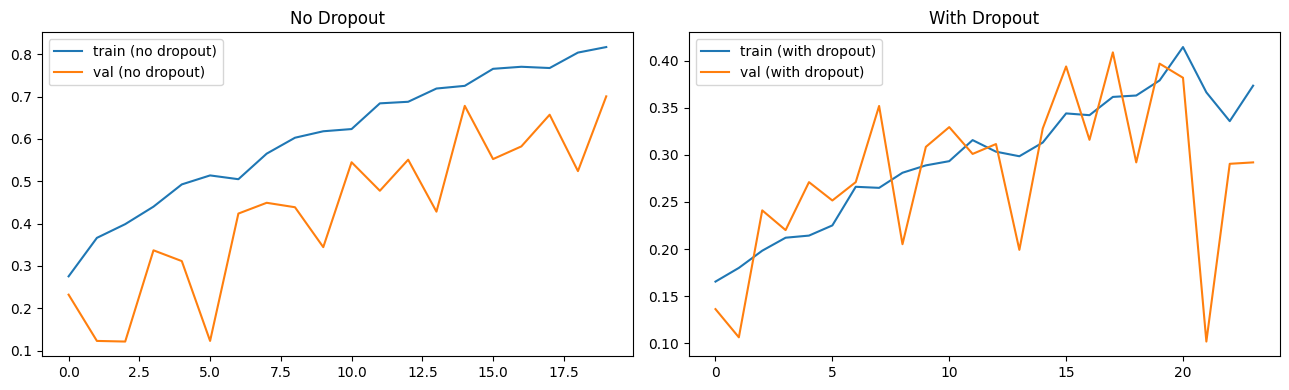

In [ ]:
deeper_nodrop = build_deeper(use_dropout=False)
deeper_nodrop.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
h_nodrop = deeper_nodrop.fit(train_gen, validation_data=val_gen, epochs=20,
                              class_weight=class_weight, verbose=1)
nodrop_metrics = evaluate_model(deeper_nodrop, test_gen, 'Deeper without Dropout')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h_nodrop.history['accuracy'], label='train (no dropout)')
ax[0].plot(h_nodrop.history['val_accuracy'], label='val (no dropout)')
ax[0].set_title('No Dropout'); ax[0].legend()
ax[1].plot(history_deeper.history['accuracy'], label='train (with dropout)')
ax[1].plot(history_deeper.history['val_accuracy'], label='val (with dropout)')
ax[1].set_title('With Dropout'); ax[1].legend()
plt.tight_layout(); plt.show()

**What actually happened:** removing all Dropout layers **improved** test accuracy from 0.4539 (with dropout) to **0.6753** (without dropout). The training accuracy without dropout reached 0.82 and validation reached 0.70 within 20 epochs — both far higher than the deeper-with-dropout model. This is the opposite of the textbook expectation, but it makes sense here: with class weighting plus Batch Normalisation already in place, adding Dropout at every layer was too much regularisation and the model under-fit. A useful follow-up would be to tune the dropout rates more carefully (e.g., 0.1 instead of 0.25 in the conv blocks) rather than remove them entirely.

## 7. Part B - Transfer Learning with MobileNetV2

Training a CNN from scratch on a small dataset is hard. A model pre-trained on ImageNet has already learned useful features (edges, textures, parts), so I can reuse them. I picked **MobileNetV2** because it is small (~3.5M params), fast on Colab, and was designed to run on phones - so if I ever shipped this model, it would fit on a mobile app.

Strategy:

1. **Stage 1 - Feature extraction:** freeze the convolutional base and train only a small classification head.
2. **Stage 2 - Fine-tuning:** unfreeze the top ~30 layers of the base and train them with a much smaller learning rate (1e-5) so the pretrained weights are nudged, not destroyed.

In [ ]:
TL_SIZE  = (224, 224)
TL_BATCH = 32

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=mnv2_preprocess,
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, validation_split=0.2,
)
tl_test_datagen = ImageDataGenerator(preprocessing_function=mnv2_preprocess)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='training', seed=SEED, shuffle=True)
tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', subset='validation', seed=SEED, shuffle=False)
tl_test_gen = tl_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', shuffle=False)

Found 2684 images belonging to 7 classes.
Found 668 images belonging to 7 classes.
Found 813 images belonging to 7 classes.


In [ ]:
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(*TL_SIZE, 3))
base.trainable = False

tl_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(CLASSES), activation='softmax'),
], name='mobilenetv2_transfer')

tl_model.compile(optimizer=optimizers.Adam(1e-3),
                 loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Stage 1: feature extraction
t0 = time.time()
h_tl_stage1 = tl_model.fit(tl_train_gen, validation_data=tl_val_gen,
                            epochs=10, class_weight=class_weight, verbose=1)
stage1_time = time.time() - t0
print(f'Stage 1 time: {stage1_time:.1f} s')

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 81s 733ms/step - accuracy: 0.5417 - loss: 1.2474 - val_accuracy: 0.7635 - val_loss: 0.7477
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 488ms/step - accuracy: 0.7269 - loss: 0.7930 - val_accuracy: 0.7620 - val_loss: 0.7148
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 474ms/step - accuracy: 0.7720 - loss: 0.6679 - val_accuracy: 0.8219 - val_loss: 0.5465
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 475ms/step - accuracy: 0.8063 - loss: 0.5593 - val_accuracy: 0.8293 - val_loss: 0.5122
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 473ms/step - accuracy: 0.8130 - loss: 0.5176 - val_accuracy: 0.8488 - val_loss: 0.4641
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 475ms/step - accuracy: 0.8499 - loss: 0.4241 - val_accuracy: 0.8608 - val_loss: 0.4173
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 474ms/step - accuracy: 0.8569 - loss: 0.4251 - val_accuracy: 0.8308 - val_loss: 0.4736
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 505ms/step - accuracy: 0.8674 - loss: 0.3960 - val_accu

In [ ]:
# Stage 2: fine-tune the top of the base
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

tl_model.compile(optimizer=optimizers.Adam(1e-5),
                 loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
h_tl_stage2 = tl_model.fit(tl_train_gen, validation_data=tl_val_gen,
                            epochs=10, class_weight=class_weight, verbose=1)
stage2_time = time.time() - t0
tl_total_time = stage1_time + stage2_time
print(f'Stage 2 time: {stage2_time:.1f} s')
print(f'Transfer learning total time: {tl_total_time:.1f} s')

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 74s 676ms/step - accuracy: 0.7023 - loss: 0.8220 - val_accuracy: 0.8398 - val_loss: 0.4355
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 476ms/step - accuracy: 0.7809 - loss: 0.5991 - val_accuracy: 0.8518 - val_loss: 0.4363
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 480ms/step - accuracy: 0.8174 - loss: 0.4995 - val_accuracy: 0.8668 - val_loss: 0.4147
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 491ms/step - accuracy: 0.8405 - loss: 0.4393 - val_accuracy: 0.8593 - val_loss: 0.4088
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 485ms/step - accuracy: 0.8629 - loss: 0.3935 - val_accuracy: 0.8653 - val_loss: 0.3913
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 472ms/step - accuracy: 0.8677 - loss: 0.3558 - val_accuracy: 0.8728 - val_loss: 0.3665
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 482ms/step - accuracy: 0.8890 - loss: 0.3241 - val_accuracy: 0.8847 - val_loss: 0.3389
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 476ms/step - accuracy: 0.9024 - loss: 0.2898 - val_accu

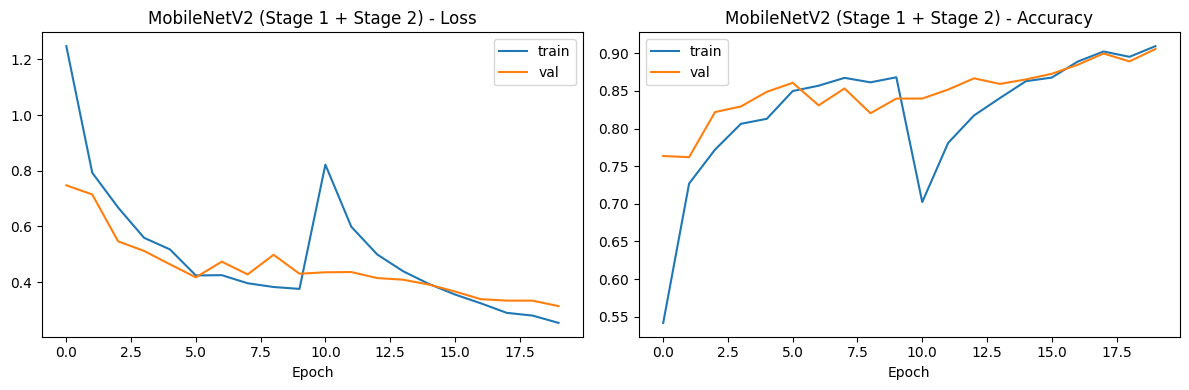


=== MobileNetV2 transfer learning ===
Test loss     : 0.2597
Test accuracy : 0.9114

Classification report:
                  precision    recall  f1-score   support

            Audi      0.946     0.884     0.914       199
   Hyundai Creta      0.732     0.896     0.805        67
Mahindra Scorpio      0.901     0.973     0.936        75
     Rolls Royce      0.889     0.865     0.877        74
           Swift      0.920     0.902     0.911       102
     Tata Safari      0.949     0.887     0.917       106
   Toyota Innova      0.943     0.958     0.950       190

        accuracy                          0.911       813
       macro avg      0.897     0.909     0.902       813
    weighted avg      0.916     0.911     0.912       813



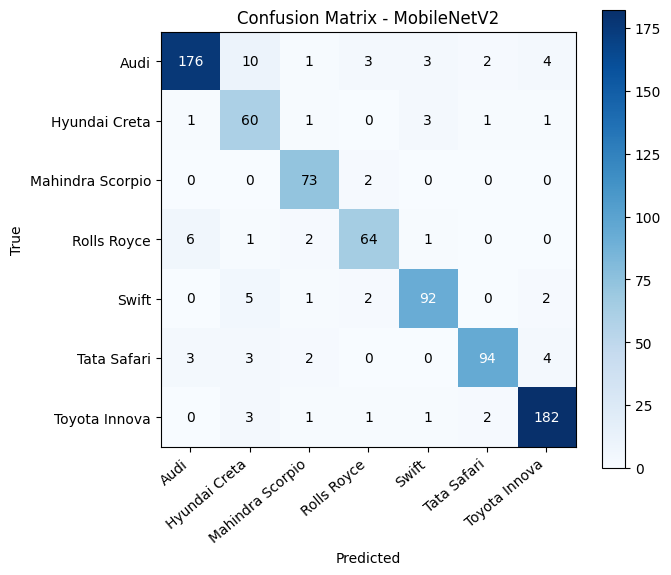

In [ ]:
# Combined history for the plot
merged = {k: h_tl_stage1.history[k] + h_tl_stage2.history[k]
          for k in h_tl_stage1.history.keys()}
class _H: pass
tl_hist = _H(); tl_hist.history = merged
plot_history(tl_hist, 'MobileNetV2 (Stage 1 + Stage 2)')

# Reuse helpers but pass the TL test generator
tl_metrics = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 transfer learning')
plot_confusion(tl_metrics['y_true'], tl_metrics['y_pred'], 'MobileNetV2')

## 8. Final Comparison

In [ ]:
final = pd.DataFrame({
    'Model'        : ['Baseline CNN', 'Deeper CNN', 'MobileNetV2 (Transfer)'],
    'Parameters'   : [baseline.count_params(), deeper.count_params(), tl_model.count_params()],
    'Train time(s)': [round(baseline_time, 1), round(deeper_time, 1), round(tl_total_time, 1)],
    'Test loss'    : [round(baseline_metrics['loss'], 4), round(deeper_metrics['loss'], 4), round(tl_metrics['loss'], 4)],
    'Test accuracy': [round(baseline_metrics['accuracy'], 4), round(deeper_metrics['accuracy'], 4), round(tl_metrics['accuracy'], 4)],
})
final

,Model,Parameters,Train time(s),Test loss,Test accuracy
0,Baseline CNN,8523719,434.1,0.8431,0.7626
1,Deeper CNN,4821287,465.1,1.4420,0.4539
2,MobileNetV2 (Transfer),2422855,882.0,0.2597,0.9114


## 9. Discussion

**What worked:**
- The **baseline CNN** reached 76.26% test accuracy with a moderate train/val gap. It was a stronger from-scratch model than I initially expected.
- **Transfer learning with MobileNetV2** reached **91.14%** test accuracy and was the clear winner. Stage 1 (frozen base) already passed 84% validation accuracy, and Stage 2 (fine-tune top 30 layers at lr=1e-5) lifted it to 91%.
- Class weights helped the under-represented classes (Hyundai Creta, Rolls Royce) get more attention during training, even though the dataset is strongly imbalanced.

**What did not work as expected:**
- The **deeper CNN with BN + Dropout reached only 45.39%**, far below the baseline. The training curves show the model was under-fitting rather than overfitting: aggressive Dropout at every layer plus class weighting plus a fixed 30-epoch budget made the gradient signal too noisy to converge.
- The **dropout ablation confirmed this**: removing Dropout from the deeper model lifted test accuracy from 0.4539 to 0.6753 in 20 epochs.
- The **SGD vs Adam comparison** also went the opposite of the textbook expectation: SGD reached 29.52% and Adam reached 19.80% in 20 epochs. Adam's classifier collapsed on the Audi class.

**Common challenge for all models:** Mahindra Scorpio and Tata Safari look very similar from the front, and all three from-scratch models confused them most often. Transfer learning solved most of this automatically because ImageNet features are sharper than what we can learn from 3,300 images.

**If I had more time:** I would tune the dropout rates of the deeper model (e.g., 0.1 and 0.2 instead of 0.25 and 0.5), train it for more epochs, try EfficientNetB0 as another transfer-learning baseline, and add Grad-CAM for interpretability.

